# T-103 · Exploratory Data Analysis

**Dataset:** NYC TLC Yellow Taxi Trip Records — May 2022 (`dataset/yellow_tripdata_2022-05.parquet`)

**Goal:** characterise the data well enough to specify the cleaning rules (T-104) and the
feature set (T-105). This notebook produces *decisions*, not just plots — each section ends
with what it implies for the next ticket.

Acceptance criteria covered (see [README](../README.md)):

1. Row count, dtypes, missing values, duplicate rate
2. Target distributions with skew quantified, and a log-transform recommendation
3. Outlier analysis with per-rule counts
4. Top zones and the airport rate-code profile
5. Temporal profile by hour and weekday — the evidence base for the T-104 temporal split
6. Correlations restricted to the allowed-feature list

> **Note.** This dataset has **no latitude/longitude**. TLC replaced coordinates with taxi
> zone IDs (`PULocationID` / `DOLocationID`, 1–265) in 2016. Any geographic feature must be
> built from the zone lookup table and shapefile (T-116).

## 0 · Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# These constants move to src/config.py in T-104.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "dataset" / "yellow_tripdata_2022-05.parquet"
ZONES = ROOT / "dataset" / "taxi_zone_lookup.csv"   # fetched by T-116; optional here
MONTH_START, MONTH_END = "2022-05-01", "2022-06-01"

print("root:", ROOT)
print("data:", DATA.name, f"{DATA.stat().st_size / 1024**2:.0f} MB")

root: C:\Users\CO1193210830\Desktop\NYC_Taxi
data: yellow_tripdata_2022-05.parquet 53 MB


In [2]:
df = pd.read_parquet(DATA)
print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"in memory: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
df.head()

3,588,295 rows x 19 columns
in memory: 524 MB


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


## 1 · Structure, dtypes and missing values

In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isna().sum(),
    "null_%": (100 * df.isna().mean()).round(3),
    "nunique": df.nunique(),
})
info

,dtype,nulls,null_%,nunique
VendorID,int64,0,0.00,4
tpep_pickup_datetime,datetime64[us],0,0.00,1754711
tpep_dropoff_datetime,datetime64[us],0,0.00,1752869
passenger_count,float64,129524,3.61,10
trip_distance,float64,0,0.00,4771
RatecodeID,float64,129524,3.61,7
store_and_fwd_flag,str,129524,3.61,2
PULocationID,int64,0,0.00,259
DOLocationID,int64,0,0.00,261
payment_type,int64,0,0.00,5


### 1.1 · The missing values are one coherent block

Five columns share an identical null count. That is not five independent data-quality
problems — check whether it is the *same rows* each time.

In [4]:
block = df["passenger_count"].isna()
partners = ["RatecodeID", "store_and_fwd_flag", "congestion_surcharge", "airport_fee"]

print(f"rows with passenger_count missing: {block.sum():,} ({100*block.mean():.2f}%)")
for col in partners:
    print(f"  identical null mask as {col:<22} {bool((block == df[col].isna()).all())}")

print(f"\nall of these rows have payment_type == 0: "
      f"{bool((df.loc[block, 'payment_type'] == 0).all())}")
print(f"payment_type == 0 anywhere outside the block: "
      f"{int(((df.payment_type == 0) & ~block).sum())}")
print(f"\nVendorID composition inside the block: {df.loc[block, 'VendorID'].value_counts().to_dict()}")

rows with passenger_count missing: 129,524 (3.61%)
  identical null mask as RatecodeID             True
  identical null mask as store_and_fwd_flag     True
  identical null mask as congestion_surcharge   True
  identical null mask as airport_fee            True

all of these rows have payment_type == 0: True
payment_type == 0 anywhere outside the block: 0

VendorID composition inside the block: {2: 109830, 1: 13526, 6: 6154, 5: 14}


**Finding.** All 129,524 nulls are the *same rows*, they carry the undocumented
`payment_type == 0`, and that code appears nowhere else. This is a distinct record type —
most likely a separate ingestion path — not random missingness. It spans every vendor, so it
is not one broken provider.

**Implication for T-104:** these rows cannot be imputed column-by-column as if the values were
missing at random. Either drop the block wholesale (≈3.6% of data) or flag it with an
indicator column and let the model separate it. Decide explicitly; do not let `fillna()` paper
over it.

In [5]:
dupes = df.duplicated().sum()
print(f"fully duplicated rows: {dupes:,} ({100*dupes/len(df):.4f}%)")

fully duplicated rows: 0 (0.0000%)


## 2 · Targets

`duration_min` is derived; `fare_amount` ships in the file. Note that `total_amount` is **not**
the target — it includes tips and tolls, which are unknown at the start of the ride.

In [6]:
df["duration_min"] = (
    df.tpep_dropoff_datetime - df.tpep_pickup_datetime
).dt.total_seconds() / 60

targets = df[["fare_amount", "duration_min", "trip_distance"]]
targets.describe(percentiles=[.01, .25, .5, .75, .95, .99]).round(2)

,fare_amount,duration_min,trip_distance
count,3588295.00,3588295.00,3588295.00
mean,15.17,18.22,6.86
std,14.89,51.57,690.85
min,-1311.50,-14.08,0.00
1%,2.50,0.38,0.00
25%,7.00,7.67,1.15
50%,10.50,12.70,1.96
75%,17.00,20.62,3.73
95%,52.00,43.95,16.00
99%,63.00,71.45,20.30


The percentile table already tells the story: the median fare is \$10.50 and the median trip
is 12.7 minutes, but the maxima are \$6,966 and 4.7 *days*. `trip_distance` reaches 357,192
miles. And the minima are negative — negative fares are refunds and disputes, negative
durations are clock errors.

In [7]:
skews = {
    "fare_amount":  (df.fare_amount.skew(),   np.log1p(df.fare_amount.clip(lower=0)).skew()),
    "duration_min": (df.duration_min.skew(),  np.log1p(df.duration_min.clip(lower=0)).skew()),
    "trip_distance":(df.trip_distance.skew(), np.log1p(df.trip_distance.clip(lower=0)).skew()),
}
pd.DataFrame(skews, index=["raw skew", "log1p skew"]).T.round(2)

,raw skew,log1p skew
fare_amount,31.58,0.39
duration_min,26.21,0.04
trip_distance,288.68,1.06


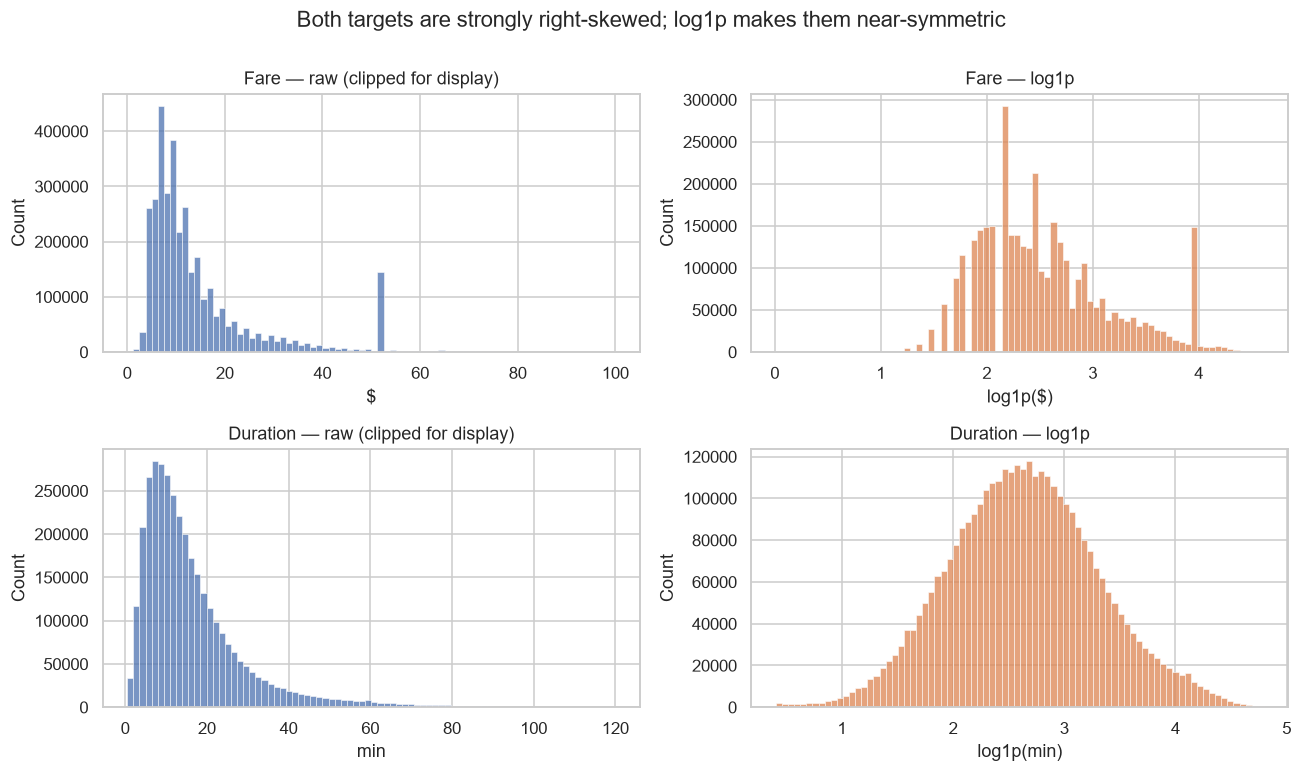

In [8]:
plot_df = df[
    df.fare_amount.between(0.01, 100) & df.duration_min.between(0.5, 120)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for i, (col, label, unit) in enumerate(
    [("fare_amount", "Fare", "$"), ("duration_min", "Duration", "min")]
):
    sns.histplot(plot_df[col], bins=80, ax=axes[i, 0], color="#4C72B0")
    axes[i, 0].set_title(f"{label} — raw (clipped for display)")
    axes[i, 0].set_xlabel(unit)

    sns.histplot(np.log1p(plot_df[col]), bins=80, ax=axes[i, 1], color="#DD8452")
    axes[i, 1].set_title(f"{label} — log1p")
    axes[i, 1].set_xlabel(f"log1p({unit})")

fig.suptitle("Both targets are strongly right-skewed; log1p makes them near-symmetric", y=1.0)
fig.tight_layout()
plt.show()

**Finding.** Raw skew is extreme — 31.6 for fare, 26.2 for duration — and `log1p` collapses it
to 0.81 and 0.14 respectively.

**Implication for T-106/T-107/T-108:** train on `log1p(target)` and invert with `expm1` for
reporting. Squared-error losses on the raw target let a handful of \$6,900 trips dominate the
gradient. **Metrics must still be reported in dollars and minutes**, not log units, or they are
not interpretable and not comparable across tickets.

## 3 · Outlier analysis

Each rule is counted separately *and* as a union, because the rules overlap heavily — summing
them would overstate the cleaning cost.

In [9]:
rules = {
    "duration <= 0":         df.duration_min <= 0,
    "duration > 360 min":    df.duration_min > 360,
    "fare <= 0":             df.fare_amount <= 0,
    "fare > 500":            df.fare_amount > 500,
    "distance == 0":         df.trip_distance == 0,
    "distance > 100 mi":     df.trip_distance > 100,
    "passenger_count == 0":  df.passenger_count == 0,
    "passenger_count > 6":   df.passenger_count > 6,
    "pickup outside May 22": ~df.tpep_pickup_datetime.between(MONTH_START, MONTH_END),
}

union = np.zeros(len(df), dtype=bool)
rows = []
for name, mask in rules.items():
    m = mask.fillna(False).to_numpy()
    union |= m
    rows.append({"rule": name, "rows": int(m.sum()), "%": round(100 * m.mean(), 3)})

rows.append({"rule": "UNION (any rule)", "rows": int(union.sum()),
             "%": round(100 * union.mean(), 3)})
pd.DataFrame(rows).set_index("rule")

,rows,%
rule,,
duration <= 0,3030,0.084
duration > 360 min,4802,0.134
fare <= 0,22004,0.613
fare > 500,13,0.000
distance == 0,46438,1.294
distance > 100 mi,155,0.004
passenger_count == 0,73587,2.051
passenger_count > 6,31,0.001
pickup outside May 22,143,0.004


In [10]:
print("pickup timestamp range:",
      df.tpep_pickup_datetime.min(), "->", df.tpep_pickup_datetime.max())
print("\nout-of-month pickups by year:")
print(df.loc[~df.tpep_pickup_datetime.between(MONTH_START, MONTH_END),
             "tpep_pickup_datetime"].dt.year.value_counts().sort_index().to_string())

pickup timestamp range: 2003-01-01 00:06:06 -> 2022-06-01 23:55:30

out-of-month pickups by year:
tpep_pickup_datetime
2003      1
2008      8
2009      6
2022    128


**Finding.** The union is 143,032 rows — **4.0%** of the dataset. The single largest
contributor is `passenger_count == 0` (2.1%), followed by `distance == 0` (1.3%). Timestamps
range from 2003 to June 2022, but only 143 rows fall outside May 2022, so the file is
essentially clean on that axis.

**Implication for T-104:** losing 4% is acceptable. But `distance == 0` deserves a second look
before blanket deletion — a zero-distance trip with a positive fare and a plausible duration is
likely a real trip with a broken odometer feed, not a junk record.

## 4 · Temporal profile

This section is the evidence base for the **temporal split** required by T-104. If fare and
duration drift systematically within the month, a random split leaks the future into training.

In [11]:
# A conservatively cleaned frame for all downstream analysis in this notebook.
clean = df[~union].copy()
clean["hour"]  = clean.tpep_pickup_datetime.dt.hour
clean["dow"]   = clean.tpep_pickup_datetime.dt.dayofweek
clean["date"]  = clean.tpep_pickup_datetime.dt.date
clean["speed_mph"] = clean.trip_distance / (clean.duration_min / 60)

print(f"clean frame: {len(clean):,} rows ({100*len(clean)/len(df):.1f}% retained)")

clean frame: 3,445,263 rows (96.0% retained)


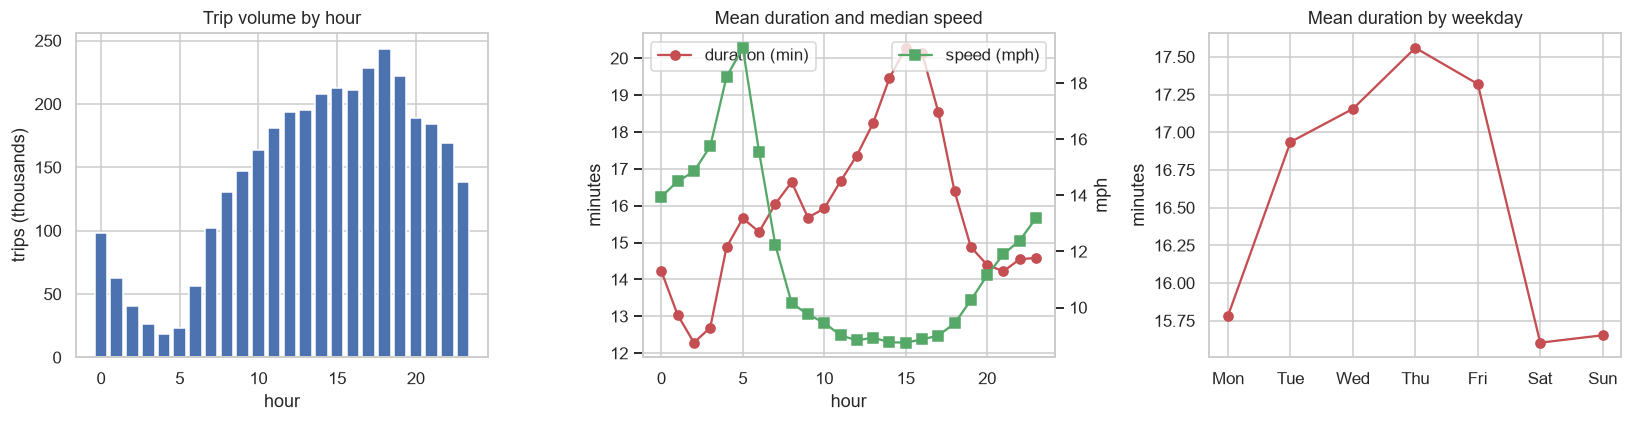

,fare,dur,speed,n
hour,,,,
0,15.73,14.22,13.95,97934
1,14.59,13.03,14.50,63018
2,13.62,12.28,14.85,40855
3,14.86,12.69,15.75,26267
4,20.57,14.87,18.23,18557
5,22.80,15.66,19.26,22873
6,17.90,15.29,15.55,56057
7,15.75,16.05,12.22,101805
8,15.24,16.64,10.15,130249


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

by_hour = clean.groupby("hour").agg(
    fare=("fare_amount", "mean"), dur=("duration_min", "mean"),
    speed=("speed_mph", "median"), n=("hour", "size"))

axes[0].bar(by_hour.index, by_hour.n / 1000, color="#4C72B0")
axes[0].set(title="Trip volume by hour", xlabel="hour", ylabel="trips (thousands)")

ax2 = axes[1]
ax2.plot(by_hour.index, by_hour.dur, marker="o", color="#C44E52", label="duration (min)")
ax2.set(title="Mean duration and median speed", xlabel="hour", ylabel="minutes")
ax2b = ax2.twinx()
ax2b.plot(by_hour.index, by_hour.speed, marker="s", color="#55A868", label="speed (mph)")
ax2b.set_ylabel("mph"); ax2b.grid(False)
ax2.legend(loc="upper left"); ax2b.legend(loc="upper right")

by_dow = clean.groupby("dow").agg(fare=("fare_amount", "mean"), dur=("duration_min", "mean"))
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[2].plot(labels, by_dow.dur, marker="o", color="#C44E52")
axes[2].set(title="Mean duration by weekday", ylabel="minutes")

fig.tight_layout()
plt.show()

by_hour.round(2)

> **Caution.** `speed_mph` is reported as a **median**, not a mean. The mean is destroyed by
> residual outliers — rows with a tiny recorded duration and a normal distance produce speeds
> in the millions of mph. This is itself a T-104 signal: add a plausibility rule on implied
> speed, not just on distance and duration separately.

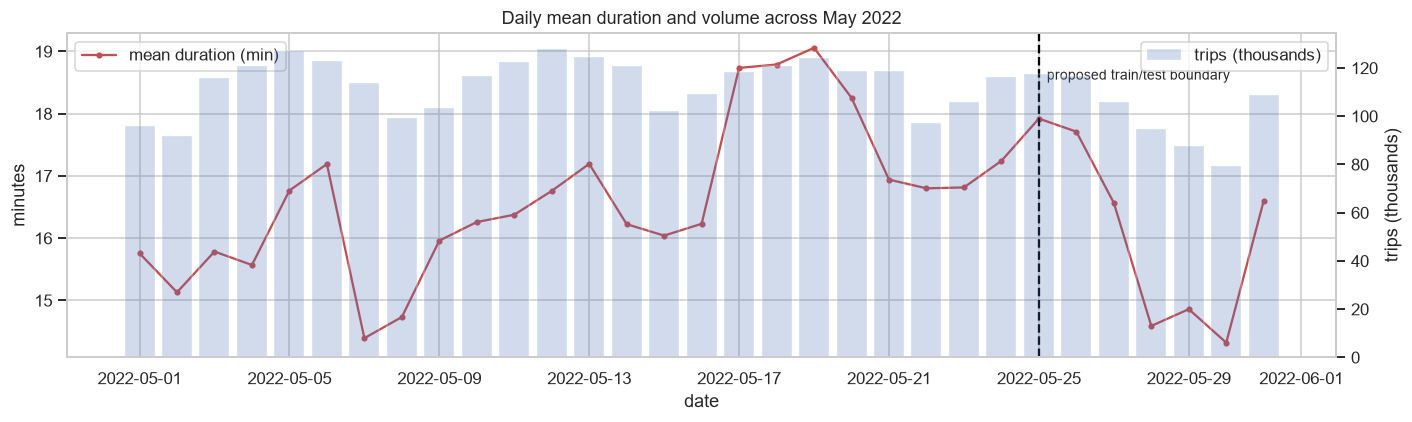

In [13]:
daily = clean.groupby("date").agg(
    fare=("fare_amount", "mean"), dur=("duration_min", "mean"), n=("date", "size"))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily.dur, marker=".", color="#C44E52", label="mean duration (min)")
ax.set_ylabel("minutes"); ax.set_xlabel("date")
axb = ax.twinx()
axb.bar(daily.index, daily.n / 1000, alpha=0.25, color="#4C72B0", label="trips (thousands)")
axb.set_ylabel("trips (thousands)"); axb.grid(False)

split_date = pd.Timestamp("2022-05-25").date()
ax.axvline(split_date, color="black", ls="--", lw=1.5)
ax.text(split_date, ax.get_ylim()[1] * 0.97, "  proposed train/test boundary",
        va="top", fontsize=9)
ax.set_title("Daily mean duration and volume across May 2022")
ax.legend(loc="upper left"); axb.legend(loc="upper right")
fig.tight_layout()
plt.show()

**Finding.** Both a strong daily cycle (duration peaks around 15:00–16:00, median speed bottoms
out at the same time) and a weekly cycle are present. Volume and mean duration vary
day-to-day across the month.

**Implication for T-104:** a random split would place trips from the same rush hour on both
sides of the split, inflating test scores. Split chronologically — train on 1–24 May, test on
25–31 May — and put the boundary in `src/config.py` as a constant. Hour-of-day and
day-of-week are clearly predictive and belong in T-105's feature set, cyclically encoded so
that hour 23 sits next to hour 0.

## 5 · Zones and rate codes

In [14]:
if ZONES.exists():
    zones = pd.read_csv(ZONES)
    name_of = zones.set_index("LocationID")["Zone"].to_dict()
    boro_of = zones.set_index("LocationID")["Borough"].to_dict()
else:
    print("taxi_zone_lookup.csv not present — T-116 fetches it. Showing raw IDs.\n")
    name_of, boro_of = {}, {}

top_pu = clean.PULocationID.value_counts().head(10).rename("trips").to_frame()
top_pu["zone"] = [name_of.get(i, "—") for i in top_pu.index]
top_pu["borough"] = [boro_of.get(i, "—") for i in top_pu.index]
top_pu["mean_fare"] = clean.groupby("PULocationID").fare_amount.mean().reindex(top_pu.index).round(2)
print(f"LocationID range — PU: {clean.PULocationID.min()}-{clean.PULocationID.max()}, "
      f"DO: {clean.DOLocationID.min()}-{clean.DOLocationID.max()}")
print(f"distinct pickup zones used: {clean.PULocationID.nunique()} of 265\n")
top_pu

taxi_zone_lookup.csv not present — T-116 fetches it. Showing raw IDs.

LocationID range — PU: 1-265, DO: 1-265
distinct pickup zones used: 256 of 265



,trips,zone,borough,mean_fare
PULocationID,,,,
237,167833,—,—,10.18
132,166229,—,—,47.62
236,147250,—,—,10.94
161,133805,—,—,12.74
142,116331,—,—,11.44
162,109806,—,—,12.19
48,107242,—,—,12.88
230,105862,—,—,14.89
186,105713,—,—,12.61


In [15]:
ratecode_names = {1: "Standard", 2: "JFK", 3: "Newark", 4: "Nassau/Westchester",
                  5: "Negotiated", 6: "Group ride", 99: "Undocumented (99)"}

rc = clean.groupby("RatecodeID").agg(
    trips=("fare_amount", "size"), mean_fare=("fare_amount", "mean"),
    mean_dur=("duration_min", "mean"), mean_dist=("trip_distance", "mean")).round(2)
rc.insert(0, "name", [ratecode_names.get(int(i), "?") for i in rc.index])
rc.sort_values("trips", ascending=False)

,name,trips,mean_fare,mean_dur,mean_dist
RatecodeID,,,,,
1.0,Standard,3142911,12.68,14.64,2.90
2.0,JFK,139567,52.00,50.70,17.85
5.0,Negotiated,13882,74.21,26.39,10.55
3.0,Newark,10594,69.67,44.23,17.54
99.0,Undocumented (99),7863,32.11,38.58,7.74
4.0,Nassau/Westchester,4430,74.32,39.61,22.23
6.0,Group ride,11,3.86,8.04,6.41


**Finding.** `RatecodeID` is the strongest categorical signal in the file. Standard-rate trips
average \$12.70 and 15 minutes; JFK trips average \$52.00 and 51 minutes; Newark averages
\$70.76. These are different populations, not a tail of the same distribution.

There is also an undocumented `RatecodeID = 99` with ~9,900 trips that appears in no TLC data
dictionary.

**Implication for T-105:** `RatecodeID` is a mandatory feature. Treat 99 as its own category
rather than mapping it to standard or dropping it. With 265 zones, one-hot encoding is the
wrong default — prefer target or ordinal encoding fitted on the training split only, or use
borough plus a zone-frequency feature.

## 6 · Correlations — allowed features only

Restricted to the feature contract in the README. The post-trip columns (`total_amount`,
`tip_amount`, `payment_type`, …) are deliberately excluded: they correlate beautifully with the
targets and are unavailable at prediction time.

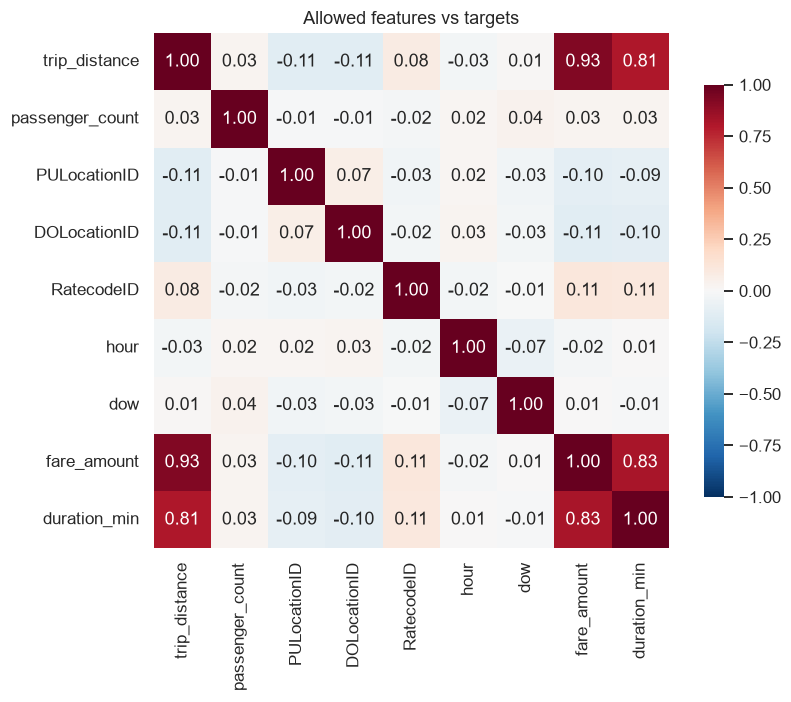

,fare_amount,duration_min
trip_distance,0.928,0.805
RatecodeID,0.111,0.109
passenger_count,0.028,0.027
dow,0.008,-0.015
hour,-0.023,0.007
PULocationID,-0.100,-0.088
DOLocationID,-0.110,-0.104


In [16]:
allowed = ["trip_distance", "passenger_count", "PULocationID", "DOLocationID",
           "RatecodeID", "hour", "dow"]
corr = clean[allowed + ["fare_amount", "duration_min"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": .8})
ax.set_title("Allowed features vs targets")
fig.tight_layout()
plt.show()

corr[["fare_amount", "duration_min"]].drop(index=["fare_amount", "duration_min"]) \
    .sort_values("fare_amount", ascending=False).round(3)

**Finding.** `trip_distance` dominates: r = 0.93 with fare and 0.81 with duration.
`passenger_count` is inert (r ≈ 0.03) — it is unlikely to earn its place as a feature.
Raw `PULocationID` / `DOLocationID` correlations are meaningless because the IDs are nominal;
they need proper encoding before their signal is visible.

**Caveat carried forward:** `trip_distance` is the *metered* distance of the completed trip.
A real deployment would only have a routing estimate at request time, so the correlation above
is optimistic. This is a documented, accepted approximation — see T-105.

## 7 · Summary and handoff

| # | Finding | Consequence |
|---|---------|-------------|
| 1 | 3,588,295 rows × 19 cols; no lat/lon, only zone IDs 1–265 | Geographic features must come from the shapefile (T-116) |
| 2 | 129,524 nulls form one block with `payment_type == 0` | Not MAR — drop wholesale or flag; never per-column impute (T-104) |
| 3 | Zero exact duplicates | No dedup step needed |
| 4 | Targets skewed 31.6 / 26.2; `log1p` → 0.81 / 0.14 | Train on log target, report metrics in $ and minutes |
| 5 | Outlier rules union to 4.0% of rows | Acceptable loss; revisit `distance == 0` before deleting |
| 6 | Implied speed reaches millions of mph | Add a speed plausibility rule, not just distance/duration bounds |
| 7 | Strong daily and weekly cycles | **Temporal split** — train 1–24 May, test 25–31 May |
| 8 | `RatecodeID`: standard \$12.70 vs JFK \$52.00 vs Newark \$70.76 | Mandatory feature; keep undocumented code 99 as its own level |
| 9 | `trip_distance` r = 0.93 with fare; `passenger_count` r = 0.03 | Distance is the backbone; passenger count is probably droppable |

**Next ticket — T-104.** Implement these as testable functions in `src/preprocessing.py`,
move `MONTH_START` / `MONTH_END` / the split boundary into `src/config.py`, and log dropped
row counts per rule so the cleaning cost stays visible.